In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import psutil

from scipy.stats import zscore

import torch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

10:34:32 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Define Marker Genes from DEG

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/sample_1_adata_basename_deg.parquet"

df = pd.read_parquet(fpath)
print(f"Raw data shape: {df.shape=}")
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

print(df.head().to_string())

Raw data shape: df.shape=(417312, 8)
                   group              names    scores  logfoldchanges     pvals  pvals_adj  pct_nz_group  pct_nz_reference
7769   endothelial_cells            MIR4454  0.200185       18.774147  0.841336   0.999989      0.000285               0.0
10261  endothelial_cells          RNU6-570P  0.035120       16.763958  0.971984   0.999989      0.000050               0.0
9989   endothelial_cells  ENSG00000286030.2  0.042144       16.398457  0.966384   0.999989      0.000060               0.0
11036  endothelial_cells            PSPC1P2  0.021072       16.307268  0.983188   0.999989      0.000030               0.0
10780  endothelial_cells            MIR5003  0.024584       15.523371  0.980387   0.999989      0.000035               0.0
CPU times: user 195 ms, sys: 75 ms, total: 270 ms
Wall time: 309 ms


# Filter

In [3]:
# read tf list
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
print(f"{len(tf_list)=}")
tf_list[:10]

len(tf_list)=1892


['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [ ]:
df['group'].unique()

In [4]:
# Define thresholds
min_logfc = 1.0
max_padj = 0.05
min_pct_group = 0.35
# max_pct_ref = 0.25

cell_types = [
    ''
]

# Apply thresholds
marker_df = df[
    # (df['names'].isin(tf_list)) &
    (df['logfoldchanges'] > min_logfc) &
    (df['pvals_adj'] < max_padj) &
    (df['pct_nz_group'] > min_pct_group) 
    # (df['pct_nz_reference'] < max_pct_ref)
]

# Optional: sort by score or logFC within each group
marker_df = marker_df.sort_values(['group', 'logfoldchanges'], ascending=[True, False])
marker_df['is_marker'] = 1
print(f"{marker_df.shape=}")
marker_df.head()

marker_df.shape=(1618, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,is_marker
25,endothelial_cells,PCAT19,282.193939,6.897974,0.0,0.0,0.407457,0.006860,1
1,endothelial_cells,CLDN5,400.676208,6.567920,0.0,0.0,0.586197,0.023174,1
22,endothelial_cells,CDH5,298.402191,6.467407,0.0,0.0,0.432864,0.009339,1
12,endothelial_cells,VWF,325.948425,6.282347,0.0,0.0,0.477586,0.017730,1
19,endothelial_cells,PTPRB,309.057892,6.259843,0.0,0.0,0.450850,0.012577,1


In [5]:
top_n_genes = 25

top_markers = (
    marker_df
    .groupby('group', group_keys=False)
    .apply(lambda g: g.nlargest(top_n_genes, 'scores'))
)

print(top_markers[['group', 'names', 'logfoldchanges', 'pct_nz_group', 'pct_nz_reference']].head().to_string(index=False))

            group  names  logfoldchanges  pct_nz_group  pct_nz_reference
endothelial_cells TM4SF1        5.577568      0.691158          0.094450
endothelial_cells  CLDN5        6.567920      0.586197          0.023174
endothelial_cells  GNG11        3.559231      0.627635          0.190901
endothelial_cells   CAV1        3.287570      0.626709          0.179484
endothelial_cells   CD59        3.003521      0.656236          0.286397


In [6]:
# Pivot into wide format: rows=genes, columns=groups, values=1 if marker
marker_mat = top_markers.pivot_table(
    index='names',
    columns='group',
    values='is_marker',
    fill_value=0
)
print(f"{marker_mat.shape=}")
marker_mat.head()

marker_mat.shape=(171, 8)


group,endothelial_cells,fibroblasts,hematopoietic_progenitors,hsc,innate_lymphoid_cells,lymphoid_cells,mesenchymal_cells,myeloid_cells
names,,,,,,,,
ACTA2,0,0,0,0,0,0,1,0
ADGRL4,1,0,0,0,0,0,0,0
AIF1,0,0,1,1,0,0,0,1
APOD,0,1,0,0,0,0,0,0
APP,1,0,0,0,0,0,0,0


# Load the data

In [7]:
%%time

start = time.perf_counter()

fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
raw_adata = sc.read_h5ad(fpath)
print(f"Raw: {raw_adata.shape=}")

raw_adata.var_names_make_unique()
raw_adata.obs_names_make_unique()

# Set X
raw_adata.X = raw_adata.layers['counts'].copy()

# add library size
lib_size = raw_adata.X.sum(1)
raw_adata.obs["size_factor"] = lib_size / np.mean(lib_size)

# drop many obs columns
to_drop = [
    "assay_ontology_term_id","cell_type_ontology_term_id",
    "development_stage_ontology_term_id", "disease",
    "disease_ontology_term_id","donor_id","is_primary_data",
    "observation_joinid","self_reported_ethnicity",
    "self_reported_ethnicity_ontology_term_id","sex",
    "sex_ontology_term_id","suspension_type", 
    "tissue_ontology_term_id","tissue_general",
    "tissue_general_ontology_term_id",
]
raw_adata.obs.drop(columns=to_drop, inplace=True)

sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

raw_adata # Return/output adata

Raw: raw_adata.shape=(1125041, 52164)
Memory usage: current 48.79 GB, difference +48.79 GB
Total time: 53.79 seconds
CPU times: user 7.71 s, sys: 34 s, total: 41.7 s
Wall time: 53.8 s


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# Sampling

In [8]:
fraction = 0.10
adata = raw_adata.copy()
adata = adata[:, marker_mat.index].copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)

print(f"Filtered: {adata.shape=}")
adata

Filtered: adata.shape=(112504, 171)


AnnData object with n_obs × n_vars = 112504 × 171
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [9]:
# Memory cleanup
del raw_adata

# Integrate our data

In [10]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
bdata = sc.read_h5ad(fpath)
bdata = bdata[:, bdata.var_names.isin(marker_mat.index)].copy()
bdata.X = bdata.layers['raw_counts'].copy()

bdata.var_names_make_unique()
bdata.obs_names_make_unique()

# add library size
lib_size = bdata.X.sum(1)
bdata.obs["size_factor"] = lib_size / np.mean(lib_size)

# column translations
bdata.obs['basename'] = np.where(bdata.obs['cluster_str'].isin(['C2', 'C3']), "reprogram", "bj_fibroblast_control")
bdata.obs['cell_type'] = bdata.obs['cluster_str']

print(bdata.obs['basename'].value_counts().to_string())
print()

print(f"Filtered: {bdata.shape=}")

bdata

basename
bj_fibroblast_control    9956
reprogram                5911

Filtered: bdata.shape=(15867, 142)
CPU times: user 1 s, sys: 2.55 s, total: 3.56 s
Wall time: 7.26 s


AnnData object with n_obs × n_vars = 15867 × 142
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'size_factor', 'basename', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'bbknn_clusters_colors', 'harmony_clusters_colors', 'hvg', 'leiden', 'log1p'

# Merge

In [11]:
%%time 

# combine
merge = an.concat(
    [adata, bdata], 
    axis=0, 
    join='inner', 
    merge='same',
    fill_value=0,
    label='batch',
)

sc.pp.filter_cells(merge, min_counts=5)
sc.pp.filter_genes(merge, min_counts=5)

merge

filtered out 791 cells that have less than 5 counts
CPU times: user 4.26 s, sys: 5.9 s, total: 10.2 s
Wall time: 10.2 s


AnnData object with n_obs × n_vars = 127580 × 142
    obs: 'cell_type', 'basename', 'n_counts', 'n_genes', 'size_factor', 'batch'
    var: 'n_counts'
    obsm: 'X_pca', 'X_umap'

In [12]:
merge.obs['batch'].value_counts()

batch
0    111713
1     15867
Name: count, dtype: int64

In [13]:
merge.obs['basename'].value_counts()

basename
lymphoid_cells               19981
fibroblasts                  19957
endothelial_cells            19891
mesenchymal_cells            19827
myeloid_cells                19631
bj_fibroblast_control         9956
hematopoietic_progenitors     6551
reprogram                     5911
hsc                           4344
innate_lymphoid_cells         1531
Name: count, dtype: int64

# Training

In [14]:
print(torch.cuda.memory_allocated() / 1e6, "MB allocated")
print(torch.cuda.memory_reserved() / 1e6, "MB reserved")

0.0 MB allocated
0.0 MB reserved


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-cfb2a8ae-864b-50df-94a5-98983023f29d]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 15 records. Best score: 187.133. Signaling Trainer to stop.
CPU times: user 1min 53s, sys: 2.37 s, total: 1min 56s
Wall time: 1min 56s


<Axes: xlabel='epoch'>

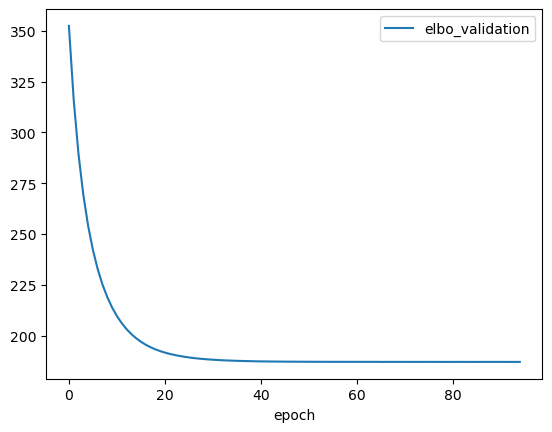

In [15]:
%%time
torch.cuda.empty_cache() 
torch.cuda.ipc_collect() 

scvi.external.CellAssign.setup_anndata(
    merge, 
    size_factor_key="size_factor",
)

model = CellAssign(merge, marker_mat)
model.train(
    max_epochs=200,
    lr=0.001,
    accelerator='gpu',
    shuffle_set_split=False,
)

model.history["elbo_validation"].plot()

In [16]:
preds = model.predict()
print(f"{preds.shape=}")
print(preds.head().to_string())

preds.shape=(127580, 8)
group  endothelial_cells   fibroblasts  hematopoietic_progenitors           hsc  innate_lymphoid_cells  lymphoid_cells  mesenchymal_cells  myeloid_cells
0           0.000000e+00  1.000000e+00               0.000000e+00  0.000000e+00           0.000000e+00    0.000000e+00       1.720484e-24   0.000000e+00
1           2.886374e-01  6.705537e-03               3.931525e-05  1.548886e-04           6.940287e-01    1.917785e-03       6.836540e-03   1.678462e-03
2           1.521176e-29  3.587576e-31               2.718999e-29  7.040219e-26           1.582895e-22    2.805510e-23       5.068875e-31   1.000000e+00
3           1.000000e+00  8.389275e-28               1.705946e-28  3.855805e-28           9.032266e-27    2.640277e-27       1.017945e-26   5.608623e-28
4           2.001411e-06  4.279540e-01               2.443472e-10  6.639592e-09           6.515003e-07    4.018631e-08       5.720478e-01   5.701526e-08


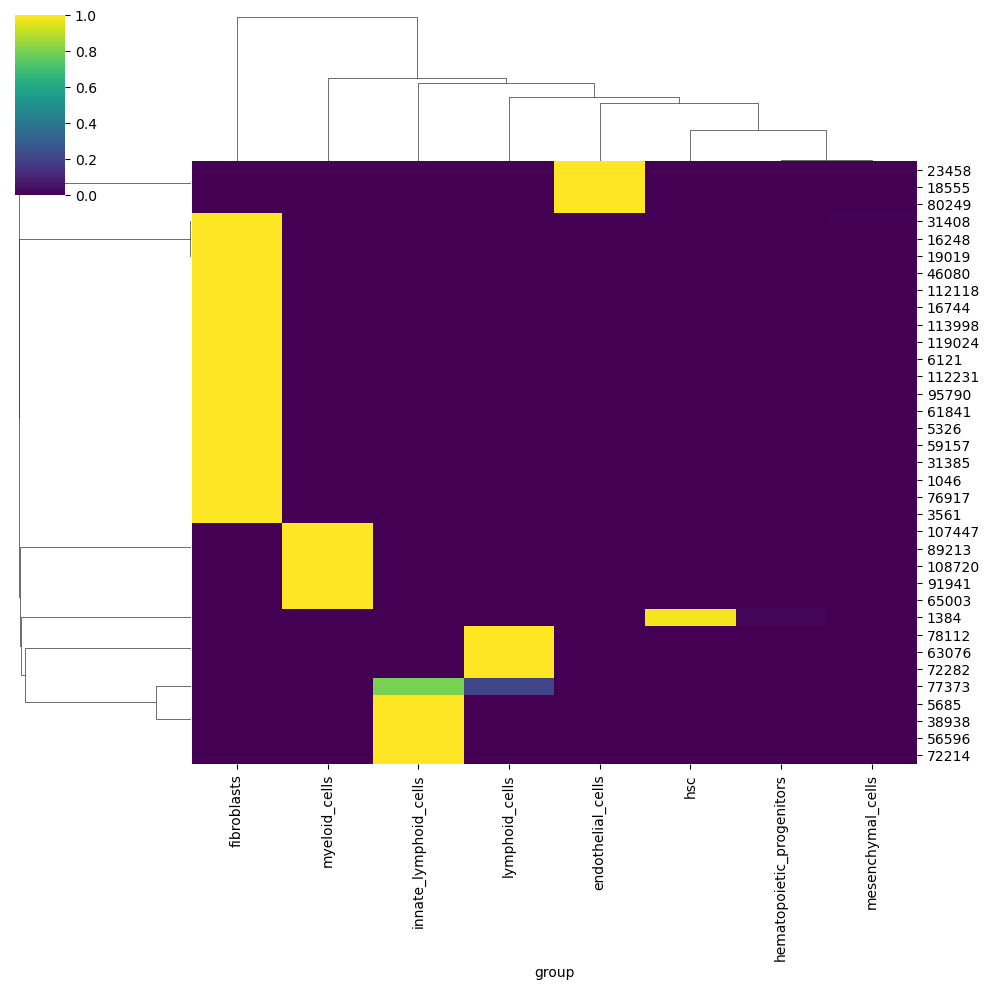

In [17]:
sns.clustermap(preds.sample(35), cmap="viridis")

In [18]:
# break

In [19]:
# Get counts
pred_counts = preds.idxmax(axis=1).value_counts().rename("predicted")
true_counts = merge.obs['basename'].value_counts().rename("true")

# Combine counts
df_counts = pd.concat([true_counts, pred_counts], axis=1).fillna(0).astype(int)

# Add difference (count)
df_counts["difference"] = df_counts["predicted"] - df_counts["true"]

# Add percentages
df_counts["true_pct"] = df_counts["true"] / df_counts["true"].sum() * 100
df_counts["predicted_pct"] = df_counts["predicted"] / df_counts["predicted"].sum() * 100
df_counts["pct_diff"] = df_counts["predicted_pct"] - df_counts["true_pct"]

# Optional: sort
df_counts["abs_pct_diff"] = df_counts["pct_diff"].abs()
df_counts = df_counts.sort_values("abs_pct_diff", ascending=False).drop(columns="abs_pct_diff")

# Format percentages to 1 decimal place
df_counts["true_pct"] = df_counts["true_pct"].round(1)
df_counts["predicted_pct"] = df_counts["predicted_pct"].round(1)
df_counts["pct_diff"] = df_counts["pct_diff"].round(1)

print(df_counts.to_string())

                            true  predicted  difference  true_pct  predicted_pct  pct_diff
fibroblasts                19957      47780       27823      15.6           37.5      21.8
mesenchymal_cells          19827       7766      -12061      15.5            6.1      -9.5
innate_lymphoid_cells       1531      12211       10680       1.2            9.6       8.4
bj_fibroblast_control       9956          0       -9956       7.8            0.0      -7.8
lymphoid_cells             19981      13621       -6360      15.7           10.7      -5.0
reprogram                   5911          0       -5911       4.6            0.0      -4.6
myeloid_cells              19631      15149       -4482      15.4           11.9      -3.5
hsc                         4344       7519        3175       3.4            5.9       2.5
hematopoietic_progenitors   6551       4203       -2348       5.1            3.3      -1.8
endothelial_cells          19891      19331        -560      15.6           15.2      -0.4

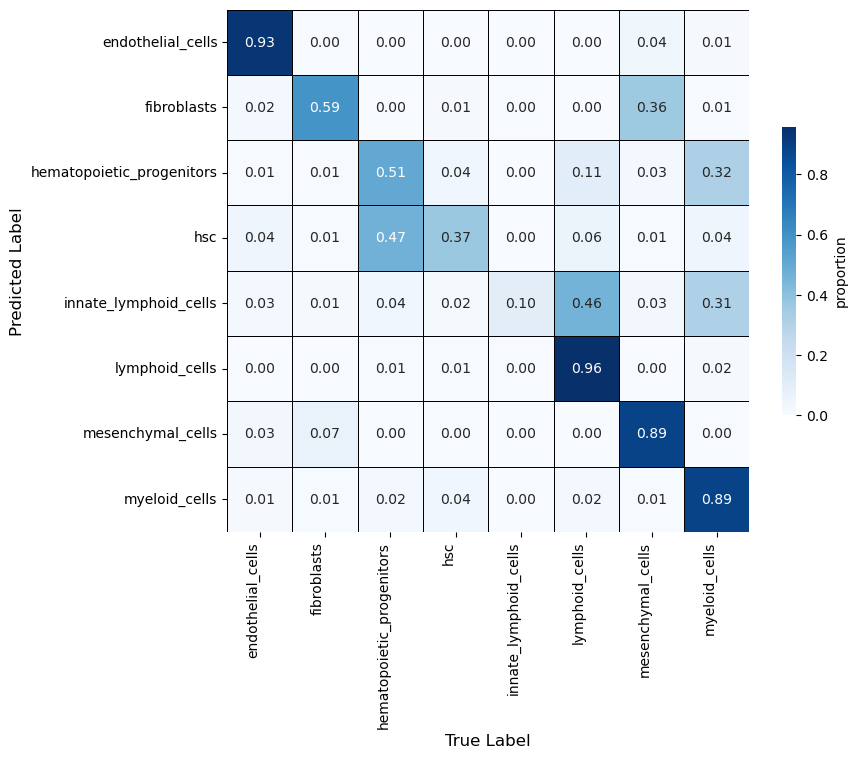

In [20]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix.drop(columns=['bj_fibroblast_control', 'reprogram'], inplace=True)

confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(9, 9))  # Square aspect
plt.rcParams['figure.dpi'] = 200
sns.heatmap(
    confusion_matrix,
    ax=ax,
    square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "proportion", "shrink": 0.4},
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_xlabel("True Label", fontsize=12)
ax.set_ylabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

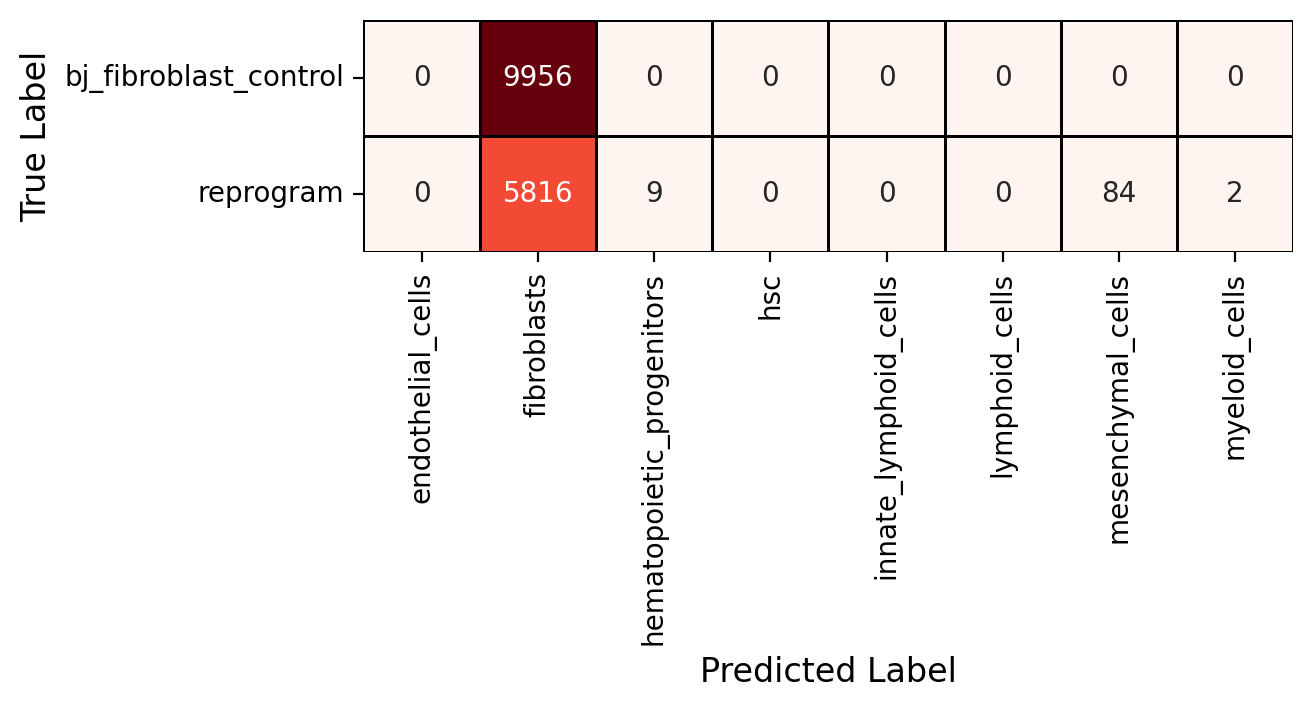

In [21]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix = confusion_matrix[['bj_fibroblast_control', 'reprogram']]
confusion_matrix

# Plot
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(6, 3))  # Square aspect
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    square=True,
    cmap="Reds",  # Use "viridis" or "mako" for alternatives
    cbar=False,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# # Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.show()

# New Embedding

In [ ]:
%%time
rsc.get.anndata_to_GPU(merge) # move to GPU

rsc.pp.pca(merge)
sc.tl.paga(merge, groups='basename')
sc.pl.paga(merge)
# rsc.pp.harmony_integrate(merge, key='batch', correction_method='fast')
# rsc.pp.neighbors(merge, n_neighbors=1000, use_rep='X_pca_harmony')

rsc.tl.draw_graph(
    merge,
    init_pos='paga'
    # min_dist=0.5,
)


sc.pl.draw_graph(
    merge, 
    color=["basename"],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)


running PAGA


# differences in probability?

In [23]:
for col in preds.columns:
    merge.obs[col] = preds[col]

merge

AnnData object with n_obs × n_vars = 127580 × 142
    obs: 'cell_type', 'basename', 'n_counts', 'n_genes', 'size_factor', 'batch', '_scvi_batch', 'endothelial_cells', 'fibroblasts', 'hematopoietic_progenitors', 'hsc', 'innate_lymphoid_cells', 'lymphoid_cells', 'mesenchymal_cells', 'myeloid_cells'
    var: 'n_counts'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'basename_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [24]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Embedding

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.25, 4.75

adata.obs['prediction'] = preds.idxmax(axis=1).values

sc.pl.tsne(
    adata,
    color=['basename', 'prediction'],
    size=35,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    palette=adata.uns['basename_palette'],
)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.75, 4.75

adata.obs['p(x)'] = preds.max(axis=1).fillna(0.0).values
min_val = adata.obs['p(x)'].min()
max_val = adata.obs['p(x)'].max()
adata.obs['p(x)_reversed_norm'] = (max_val - adata.obs['p(x)']) / (max_val - min_val)

sc.pl.tsne(
    adata,
    color=['p(x)_reversed_norm'],
    sort_order=True,
    size=32,
    ncols=4,
    alpha=0.75,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    title=['uncertainty'],
    cmap='inferno',
)

In [ ]:
break

# with pangloa

In [ ]:
print(torch.cuda.memory_allocated() / 1e6, "MB allocated")
print(torch.cuda.memory_reserved() / 1e6, "MB reserved")

In [ ]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

fpath = "../../resources/PanglaoDB_Augmented_2021.txt"
pdf = load_pathway(fpath)
cell_types = ['Hematopoietic Stem Cells', 'Endothelial Cells', 'Fibroblasts']

pdf = pdf[pdf[cell_types].any(axis=1)][cell_types]
print(f"Raw: {pdf.shape=}")
pdf = pdf.astype(int)
pdf = pdf[pdf.index.isin(raw_adata.var_names)]
print(f"Filtered: {pdf.shape=}")
pdf.head()

# Sampling

In [ ]:
fraction = 0.15
adata = raw_adata.copy()
adata = adata[:, pdf.index].copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)
print(f"Filtered: {raw_adata.shape=}")

adata

In [ ]:
%%time
torch.cuda.empty_cache() 
torch.cuda.ipc_collect() 

scvi.external.CellAssign.setup_anndata(
    adata, 
    size_factor_key="size_factor",
    layer='counts',
)

model = CellAssign(adata, marker_mat)
model.train(
    max_epochs=200,
    lr=0.001,
    accelerator='gpu',
    shuffle_set_split=False,
)

model.history["elbo_validation"].plot()

In [ ]:
preds = model.predict()
print(f"{preds.shape=}")
print(preds.head().to_string())

In [ ]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    adata.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(9, 9))  # Square aspect
sns.heatmap(
    confusion_matrix,
    ax=ax,
    square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "proportion", "shrink": 0.4},
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_xlabel("True Label", fontsize=12)
ax.set_ylabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.25, 4.75

adata.obs['prediction'] = preds.idxmax(axis=1).values

sc.pl.tsne(
    adata,
    color=['basename', 'prediction'],
    size=35,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    palette=adata.uns['basename_palette'],
)